0.9999901155205898


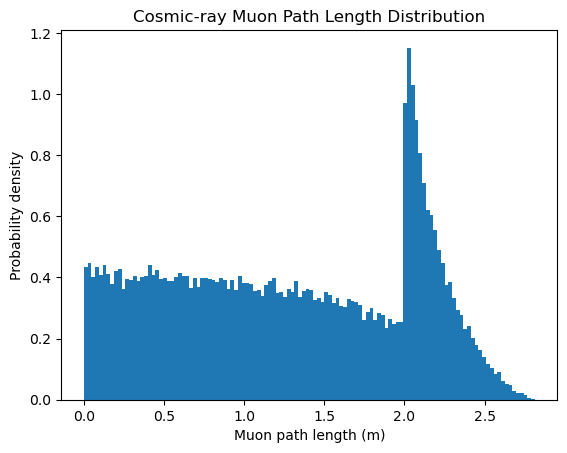

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Detector geometry
# ----------------------------
R = 1.0
H = 2
a = 1.3 #cos^a muon distribution
N = 100_000  #Number of events -  easily scalable to 10M+

# ----------------------------
# Entry points (top surface)
# ----------------------------
r = R * np.sqrt(np.random.rand(N)) #radius coordinate of each event (sqrt because area scales by r^2 and would clump in middle)
print(np.max(r)) #Verifies that rmax approachs R
phi = 2*np.pi*np.random.rand(N) #random number in full range of phi when looking at top circle

x0 = r*np.cos(phi) #translates polar to cartesian
y0 = r*np.sin(phi) #translates polar to cartesian
z0 = np.full(N, H/2) #places top circle at top of cylinder when cylinder centered at z=0, and places all events on this circle

# ----------------------------
# Cosmic-ray angular distribution
# approx cos^2(theta)
# ----------------------------
theta = np.arccos(np.random.rand(N)) #Allows for even distribution of random events from sky with theta=0 being straight up
phi_dir = 2*np.pi*np.random.rand(N) #Even distribution for phi, same axis/plane as before but gives path rather than starting point on circle

accept = np.random.rand(N) < np.power(np.cos(theta),a) #Makes array that throws out events in accordance with probability of muons falling at certain theta values
theta = theta[accept] #Applies above array to all values
phi_dir = phi_dir[accept]

x0 = x0[accept]
y0 = y0[accept]
z0 = z0[accept]

# direction vectors (unit vectors for each event)
vx = np.sin(theta)*np.cos(phi_dir) #creates a unit vector in the direction of travel for each muon, 
vy = np.sin(theta)*np.sin(phi_dir)
vz = -np.cos(theta)

# ----------------------------
# Cylinder wall intersection
# ----------------------------
a = vx**2 + vy**2 #Uses R^2=x^2+y^2 and parametric description of line of muon travel x=vl+x_0 and y=vl+y0 to get quadratic equation that can be solved for length travelled
b = 2*(x0*vx + y0*vy)
c = x0**2 + y0**2 - R**2

disc = b**2 - 4*a*c #describes discriminanat
disc[disc < 0] = np.nan #discards imaginary results from the quadratic solution where the muon never touches the wall

t1 = (-b + np.sqrt(disc))/(2*a) #calculation for lengths (times?) travlled to satisfy equations above
t2 = (-b - np.sqrt(disc))/(2*a)

# keep forward solutions
#t_side = np.where((t1 > 0) & (t1 < t2), t1, t2)
t_side = np.where((t1 > 0), t1, t2) #discards points where muon passes through infintely tall cylinder wall above H/2, so doesn't really hit our detector

# ----------------------------
# Bottom cap intersection
# ----------------------------
t_bottom = (-H/2 - z0)/vz #descibes the time/length to the bottom of the detector
t_bottom[t_bottom <= 0] = np.nan #discards negative times so only solutions are the ones actually hitting the bottom of the detector

# ----------------------------
# Choose first exit
# ----------------------------
t_exit = np.nanmin(np.vstack([t_side, t_bottom]), axis=0) #picks the smallest real number of time to bottom or side, since it really only hits one even though we used infinite planes

# path lengths

vnorm = np.sqrt(vx**2 + vy**2 + vz**2) #redundant calculation?

lengths = t_exit * vnorm #redundant calculation?

# remove NaNs
lengths = lengths[np.isfinite(lengths)] #removes discarded values from plot and infinite lengths when for example theta=0
# ----------------------------
# Histogram
# ----------------------------
plt.hist(lengths, bins=120, density=True) #Plots probability density function of lengths travelled
plt.yscale('linear')
plt.xlabel("Muon path length (m)")
plt.ylabel("Probability density")
plt.title("Cosmic-ray Muon Path Length Distribution")
plt.show()

0.999993867389956


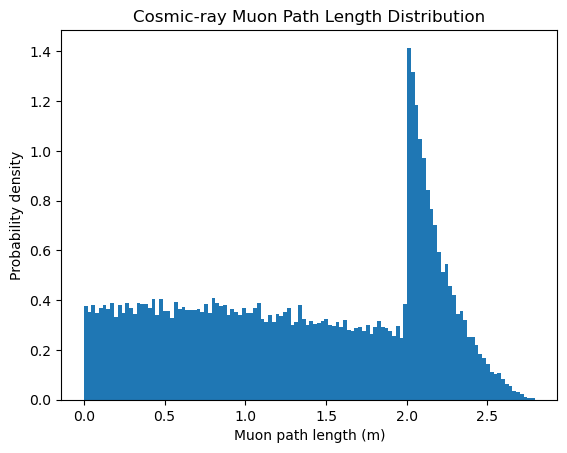

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Detector geometry
# ----------------------------
R = 1.0
H = 2
a = 2 #cos^a muon distribution
N = 100_000  #Number of events -  easily scalable to 10M+

# ----------------------------
# Entry points (top surface)
# ----------------------------
r = R * np.sqrt(np.random.rand(N)) #radius coordinate of each event (sqrt because area scales by r^2 and would clump in middle)
print(np.max(r)) #Verifies that rmax approachs R
phi = 2*np.pi*np.random.rand(N) #random number in full range of phi when looking at top circle

x0 = r*np.cos(phi) #translates polar to cartesian
y0 = r*np.sin(phi) #translates polar to cartesian
z0 = np.full(N, H/2) #places top circle at top of cylinder when cylinder centered at z=0, and places all events on this circle

# ----------------------------
# Cosmic-ray angular distribution
# approx cos^2(theta)
# ----------------------------
theta = np.arccos(np.random.rand(N)) #Allows for even distribution of random events from sky with theta=0 being straight up
phi_dir = 2*np.pi*np.random.rand(N) #Even distribution for phi, same axis/plane as before but gives path rather than starting point on circle

accept = np.random.rand(N) < np.power(np.cos(theta),a) #Makes array that throws out events in accordance with probability of muons falling at certain theta values
theta = theta[accept] #Applies above array to all values
phi_dir = phi_dir[accept]

x0 = x0[accept]
y0 = y0[accept]
z0 = z0[accept]

# direction vectors (unit vectors for each event)
vx = np.sin(theta)*np.cos(phi_dir) #creates a unit vector in the direction of travel for each muon, 
vy = np.sin(theta)*np.sin(phi_dir)
vz = -np.cos(theta)

# ----------------------------
# Cylinder wall intersection
# ----------------------------
a = vx**2 + vy**2 #Uses R^2=x^2+y^2 and parametric description of line of muon travel x=vl+x_0 and y=vl+y0 to get quadratic equation that can be solved for length travelled
b = 2*(x0*vx + y0*vy)
c = x0**2 + y0**2 - R**2

disc = b**2 - 4*a*c #describes discriminanat
disc[disc < 0] = np.nan #discards imaginary results from the quadratic solution where the muon never touches the wall

t1 = (-b + np.sqrt(disc))/(2*a) #calculation for lengths (times?) travlled to satisfy equations above
t2 = (-b - np.sqrt(disc))/(2*a)

# keep forward solutions
#t_side = np.where((t1 > 0) & (t1 < t2), t1, t2)
t_side = np.where((t1 > 0), t1, t2) #discards points where muon passes through infintely tall cylinder wall above H/2, so doesn't really hit our detector

# ----------------------------
# Bottom cap intersection
# ----------------------------
t_bottom = (-H/2 - z0)/vz #descibes the time/length to the bottom of the detector
t_bottom[t_bottom <= 0] = np.nan #discards negative times so only solutions are the ones actually hitting the bottom of the detector

# ----------------------------
# Choose first exit
# ----------------------------
t_exit = np.nanmin(np.vstack([t_side, t_bottom]), axis=0) #picks the smallest real number of time to bottom or side, since it really only hits one even though we used infinite planes

# path lengths

vnorm = np.sqrt(vx**2 + vy**2 + vz**2) #redundant calculation?

lengths = t_exit * vnorm #redundant calculation?

# remove NaNs
lengths = lengths[np.isfinite(lengths)] #removes discarded values from plot and infinite lengths when for example theta=0
# ----------------------------
# Histogram
# ----------------------------
plt.hist(lengths, bins=120, density=True) #Plots probability density function of lengths travelled
plt.yscale('linear')
plt.xlabel("Muon path length (m)")
plt.ylabel("Probability density")
plt.title("Cosmic-ray Muon Path Length Distribution")
plt.show()

0.9986292294761173


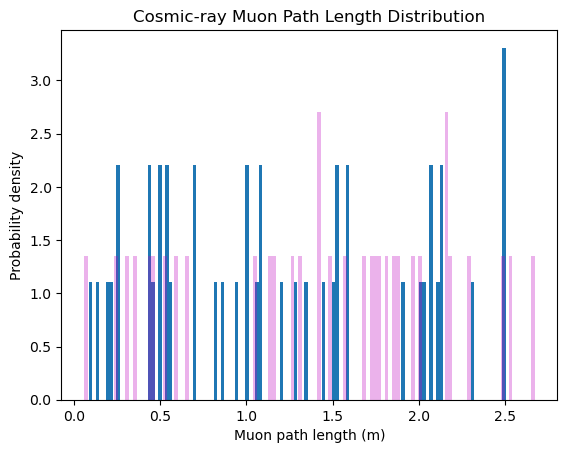

In [2]:
#try different a, is it different?
a = 2.0

# ----------------------------
# Entry points (top surface)
# ----------------------------
r = R * np.sqrt(np.random.rand(N))
print(np.max(r))
phi = 2*np.pi*np.random.rand(N)

x0 = r*np.cos(phi)
y0 = r*np.sin(phi)
z0 = np.full(N, H/2)

# ----------------------------
# Cosmic-ray angular distribution
# approx cos^2(theta)
# ----------------------------
theta = np.arccos(np.random.rand(N))
phi_dir = 2*np.pi*np.random.rand(N)

accept = np.random.rand(N) < np.power(np.cos(theta),a)
theta = theta[accept]
phi_dir = phi_dir[accept]

x0 = x0[accept]
y0 = y0[accept]
z0 = z0[accept]

# direction vectors
vx = np.sin(theta)*np.cos(phi_dir)
vy = np.sin(theta)*np.sin(phi_dir)
vz = -np.cos(theta)

# ----------------------------
# Cylinder wall intersection
# ----------------------------
a = vx**2 + vy**2
b = 2*(x0*vx + y0*vy)
c = x0**2 + y0**2 - R**2

disc = b**2 - 4*a*c
disc[disc < 0] = np.nan

t1 = (-b + np.sqrt(disc))/(2*a)
t2 = (-b - np.sqrt(disc))/(2*a)

# keep forward solutions
#t_side = np.where((t1 > 0) & (t1 < t2), t1, t2)
t_side = np.where((t1 > 0), t1, t2)

# ----------------------------
# Bottom cap intersection
# ----------------------------
t_bottom = (-H/2 - z0)/vz
t_bottom[t_bottom <= 0] = np.nan

# ----------------------------
# Choose first exit
# ----------------------------
t_exit = np.nanmin(np.vstack([t_side, t_bottom]), axis=0)

# path lengths

vnorm = np.sqrt(vx**2 + vy**2 + vz**2)

lengths1 = t_exit * vnorm

# remove NaNs
lengths1 = lengths1[np.isfinite(lengths1)]

# ----------------------------
# Histogram
# ----------------------------
plt.hist(lengths, bins=120, density=True)
plt.hist(lengths1, bins=120, density=True, alpha=0.3, color = 'm')
plt.yscale('linear')
plt.xlabel("Muon path length (m)")
plt.ylabel("Probability density")
plt.title("Cosmic-ray Muon Path Length Distribution")
plt.show()